In [2]:
import sys
sys.path.append('../')
from module.optics.slit import plot2_DoubleSlitContrast
from module.optics.knife_edge import plot_DoubleKnifeEdge, intensity_DoubleKnifeEdge, intensity_KnifeEdge
from module.optics.arago_spot import intensity_arago, intensity_arago_2D
from module.optics.general_diffraction import intensity_diffraction
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('dark_background')

# Double Slit

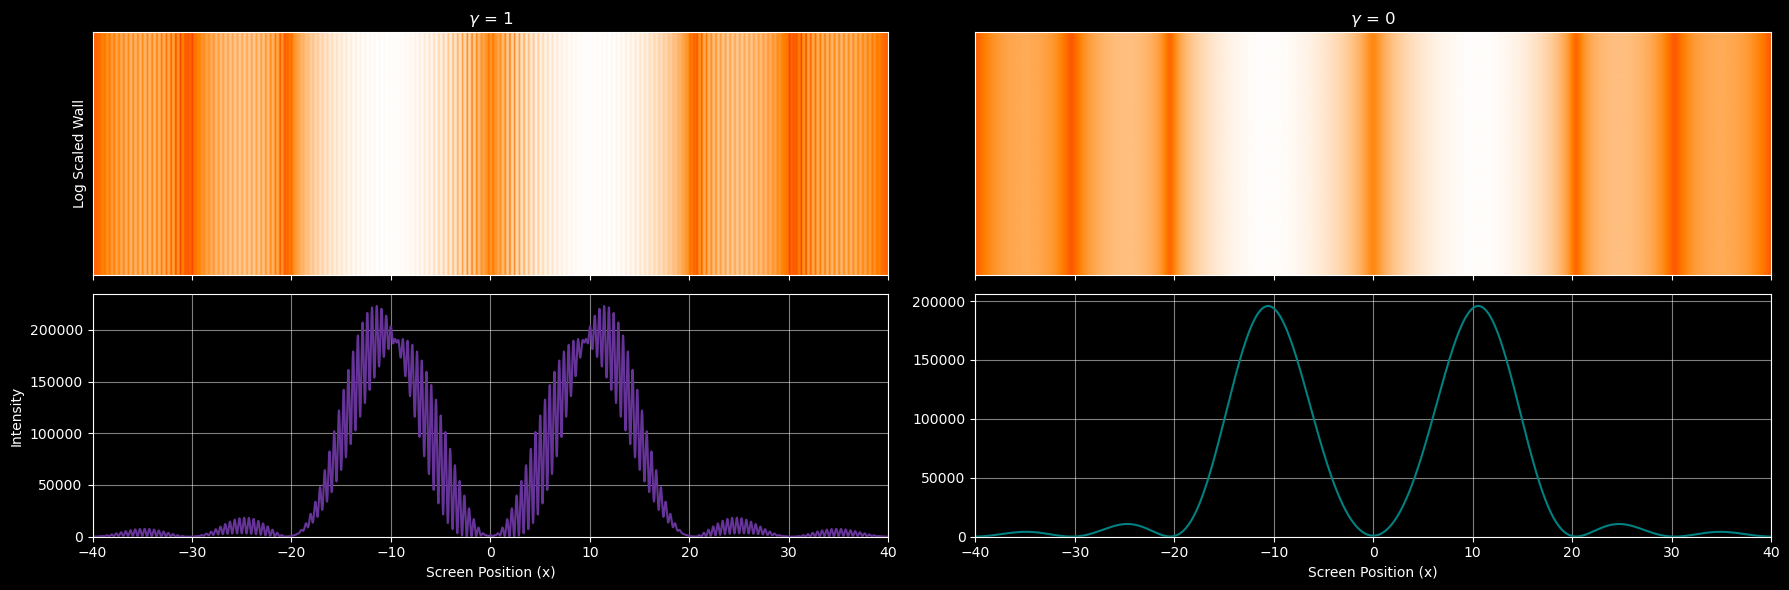

In [3]:
x = np.linspace(-40, 40, 100000)
params = {
    'amplitude': 25,
    'wavelength': 1.0,       # 5x longer waves (makes fringes wider and visible)
    'slit_width': 1.0,       # 10x wider slits (controls the width of the hills)
    'slit_distance': 20,     # Pushes the hills further apart to x = -10 and x = 10
    'screen_distance': 10    # Pushes the screen back slightly
}

plot2_DoubleSlitContrast(x, params)

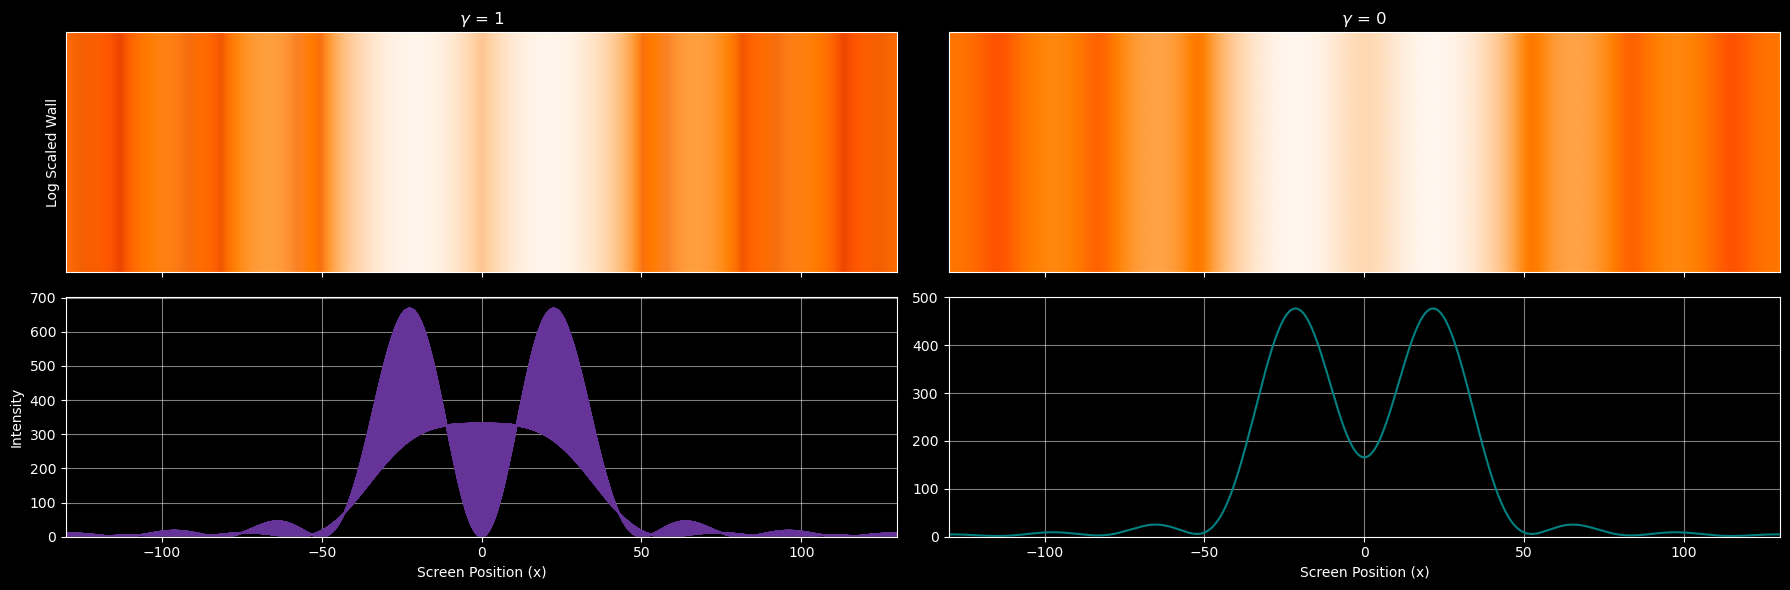

In [4]:
x = np.linspace(-130, 130, 100000)
params = {
    'amplitude': 55,
    'wavelength': 0.2,     
    'slit_width': 0.1,     
    'slit_distance': 42,   
    'screen_distance': 16
}

plot2_DoubleSlitContrast(x, params)

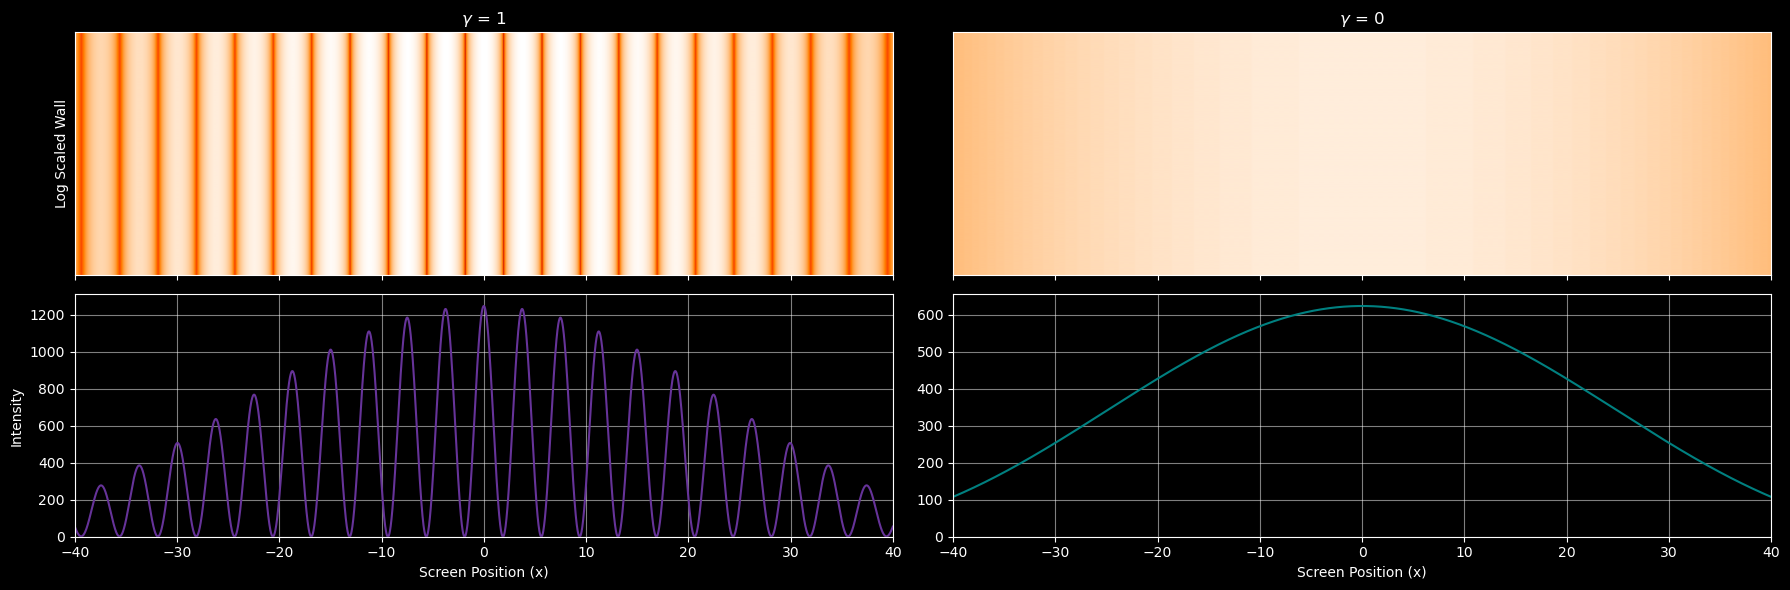

In [5]:
x = np.linspace(-40, 40, 100000)
params = {
    'amplitude': 25,
    'wavelength': 1.2,
    'slit_width': 0.2,
    'slit_distance': 3,
    'screen_distance': 10
}

plot2_DoubleSlitContrast(x, params)

# Knife-Edge Diffraction

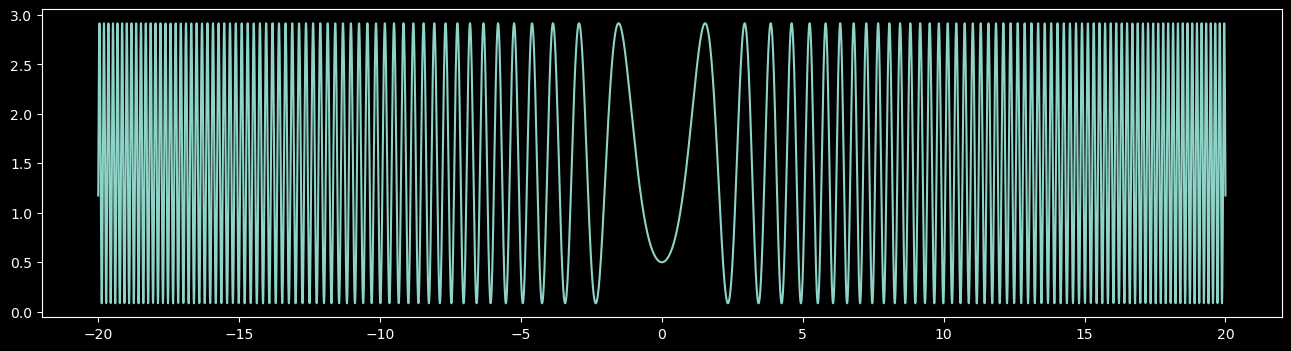

In [6]:
x = np.linspace(-20,20,10000)
y = ((1/2 + np.sin(x**2))**2 + (1/2 - np.cos(x**2))**2)

plt.figure(figsize=(16,4))
plt.plot(x,y)

keep in mind the above equation is simplified. The actual formula contains an envelope on the amplitude

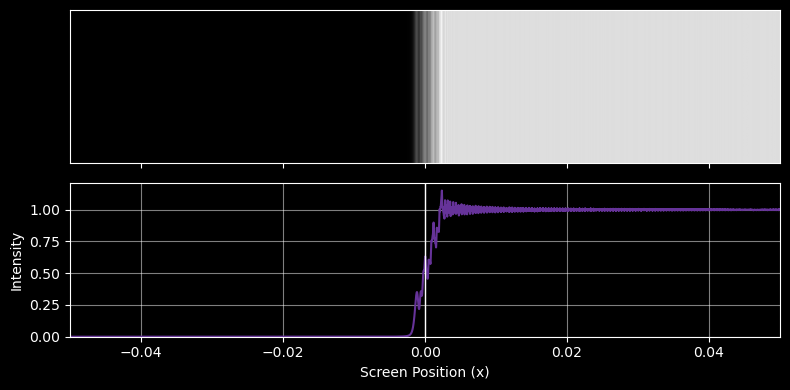

In [7]:
angles = np.linspace(-0.1,0.1,4)
x = np.linspace(-0.05,0.05,10000)
z=1

total_intensity = np.zeros_like(x)
for a in angles:
        total_intensity += intensity_KnifeEdge(x, z, amplitude=1, wavelength=460e-9, theta_degrees=a)
total_intensity = total_intensity / len(angles)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 4), sharex=True)
I_2D = np.tile(total_intensity, (100, 1))
ax1.imshow(I_2D, extent=[x.min(), x.max(), 0, 1], cmap='gray', aspect='auto')
ax1.set_yticks([])

ax2.plot(x, total_intensity, color='rebeccapurple')
ax2.set_ylabel("Intensity")
ax2.set_xlabel("Screen Position (x)")
ax2.axvline(0, linewidth=1)
ax2.grid(True, alpha=0.5)
ax2.set_xlim(np.min(x), np.max(x))
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

![](../images/optics/knife_edge.jpeg)

![](knife_edge.jpeg)

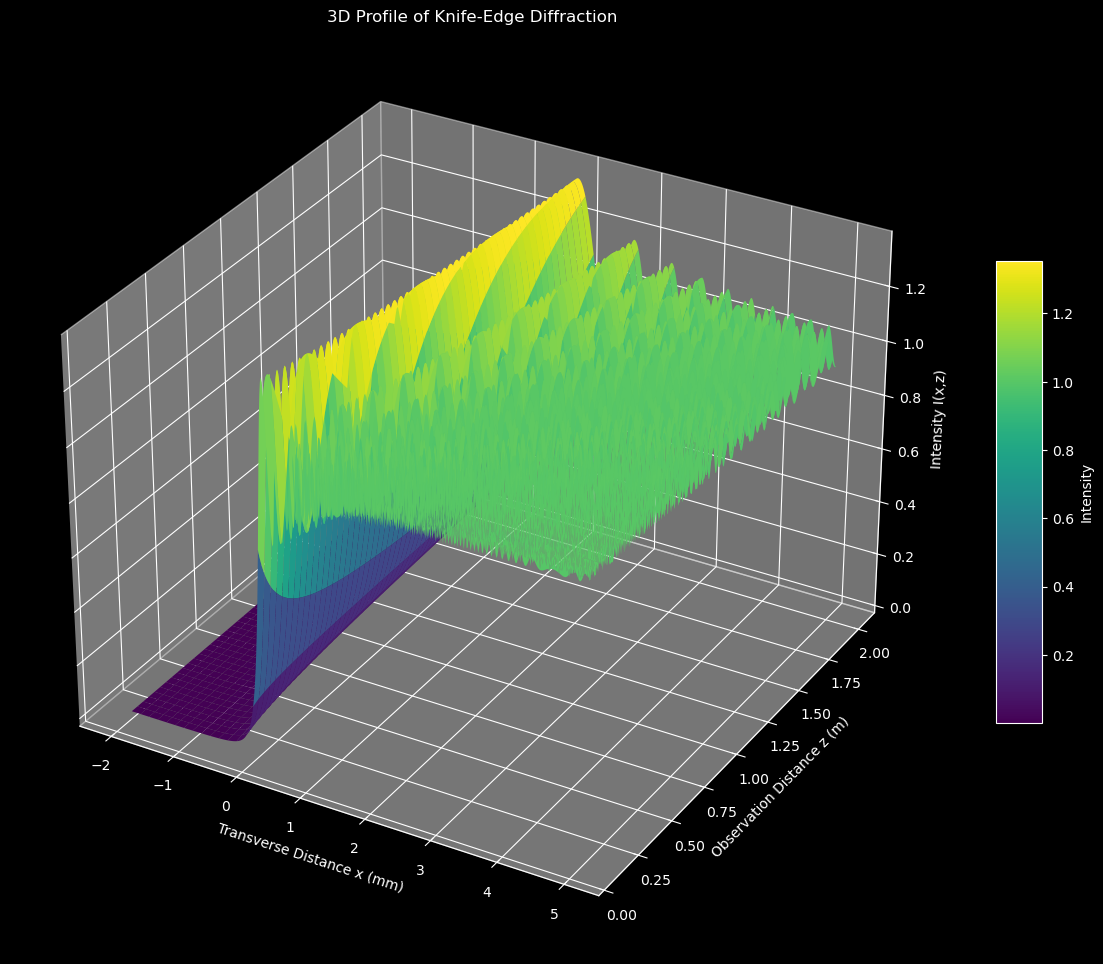

In [8]:
wavelength = 632.8e-9  # 632.8 nm (Red HeNe laser) in meters
amplitude = 1.0        # Normalized background intensity

x_vals = np.linspace(-0.002, 0.005, 500) 
z_vals = np.linspace(0.1, 2.0, 500)      
X, Z = np.meshgrid(x_vals, z_vals)
Intensity = intensity_KnifeEdge(X, Z, amplitude, wavelength)


fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# x in mm
surf = ax.plot_surface(X * 1000, Z, Intensity, cmap='viridis', edgecolor='none')

ax.set_title('3D Profile of Knife-Edge Diffraction')
ax.set_xlabel('Transverse Distance x (mm)')
ax.set_ylabel('Observation Distance z (m)')
ax.set_zlabel('Intensity I(x,z)')

fig.colorbar(surf, shrink=0.5, aspect=10, label='Intensity')

plt.show()

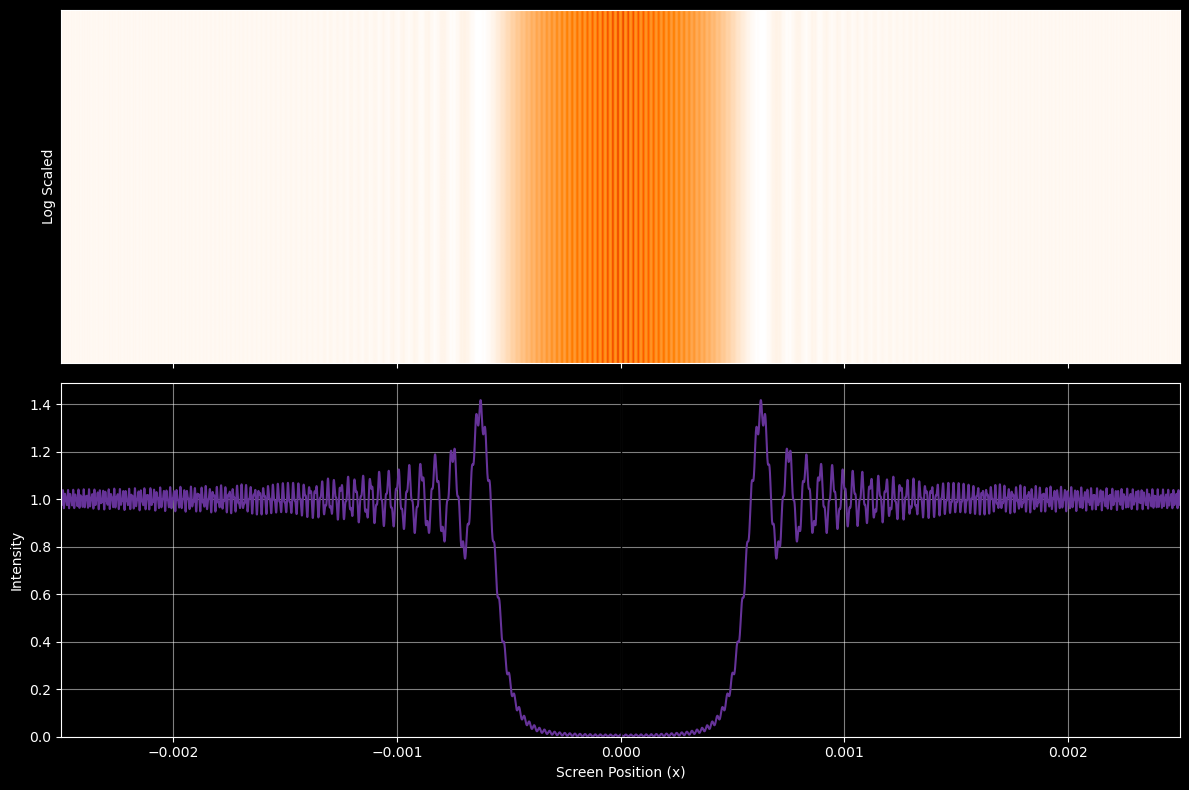

In [9]:
params = {
    'd': 1e-3,
    'amplitude': 1,
    'wavelength': 455e-9
}
z = 0.05
x = np.linspace(-0.0025, 0.0025, int(1e5)) 

plot_DoubleKnifeEdge(x, z, **params)

![](../images/optics/knife_edge2.jpeg)

Text(0, 0.5, 'Intensity @ x=0')

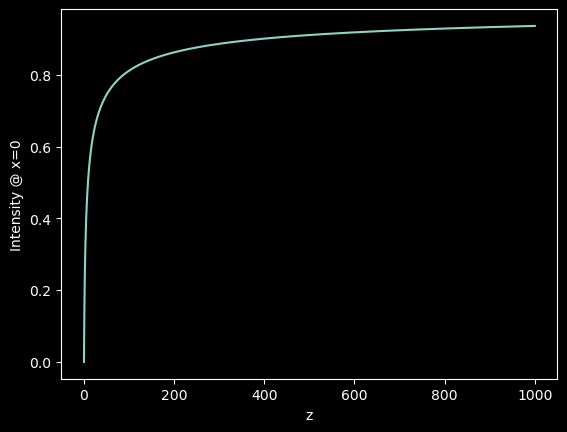

In [10]:
z = np.linspace(1e-6,1e3,1000)
I = intensity_DoubleKnifeEdge(x=0, z=z, d=1e-3, amplitude=1, wavelength=455e-9)

plt.plot(z,I)
plt.xlabel('z')
plt.ylabel('Intensity @ x=0')

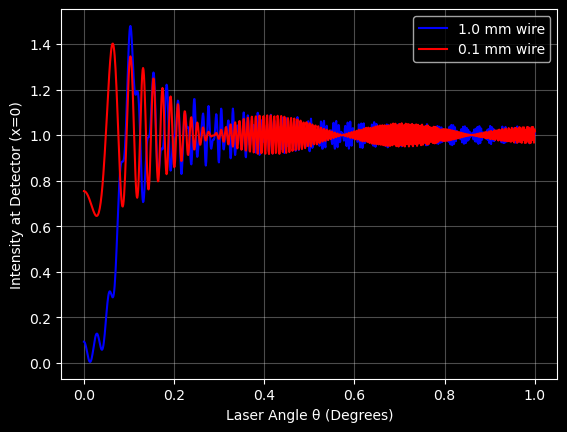

In [11]:
x_fixed = 0.0
theta_sweep = np.linspace(0, 1, 1000)

I_dark_center = intensity_DoubleKnifeEdge(
    x=x_fixed, z=0.5, d=1.0e-3, amplitude=1, wavelength=500e-9, theta_degrees=theta_sweep
)

I_bright_center = intensity_DoubleKnifeEdge(
    x=x_fixed, z=0.5, d=0.1e-3, amplitude=1, wavelength=500e-9, theta_degrees=theta_sweep
)


plt.plot(theta_sweep, I_dark_center, label='1.0 mm wire', color='blue')
plt.plot(theta_sweep, I_bright_center, label='0.1 mm wire', color='red')
plt.xlabel('Laser Angle \u03b8 (Degrees)')
plt.ylabel('Intensity at Detector (x=0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Arago Spot

normal incident plane wave only

In [12]:
def plot_arago(r, n_r, z, wavelength, disk_radius, I0, n_xy=500, n_rp=5000):
    """
    all units in m
    """
    params = {
        'wavelength': wavelength,
        'z': z,  
        'disk_radius': disk_radius,
        'I0': I0,
        'n_rp': n_rp
    }

    # extend r for corners
    r_vals_ext = np.linspace(0, r * np.sqrt(2), int(n_r * 1.5))
    I_vals_ext = intensity_arago(r_vals_ext, **params)

    # trim for plotting intensity
    mask = r_vals_ext <= r
    r_vals = r_vals_ext[mask]
    I_vals = I_vals_ext[mask]
    r_vals_full = np.concatenate((-r_vals[::-1], r_vals[1:]))
    I_vals_full = np.concatenate((I_vals[::-1], I_vals[1:]))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.plot(r_vals_full * 1000, I_vals_full, color='cyan')
    ax1.set_xlabel("Radius r (mm)")
    ax1.set_ylabel("Relative Intensity ($I/I_0$)", fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(r_vals_full.min()* 1000, r_vals_full.max()* 1000)
    ax1.set_facecolor('black')

    x_1d = np.linspace(-r, r, n_xy)
    y_1d = np.linspace(-r, r, n_xy)
    X, Y = np.meshgrid(x_1d, y_1d)

    R = np.sqrt(X**2 + Y**2)
    I_2D = np.interp(R, r_vals_ext, I_vals_ext) # assumes intensity is the same along a circle of radius R, evaluate intensity as a function of r only since we know radial symmetry
    r_mm = r * 1000
    im = ax2.imshow(I_2D, extent=[-r_mm, r_mm, -r_mm, r_mm], cmap='inferno', origin='lower')
    ax2.set_xlabel("x (mm)", fontsize=12)
    ax2.set_ylabel("y (mm)", fontsize=12)

    cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label("Intensity", labelpad=15)

    plt.tight_layout()
    plt.show()

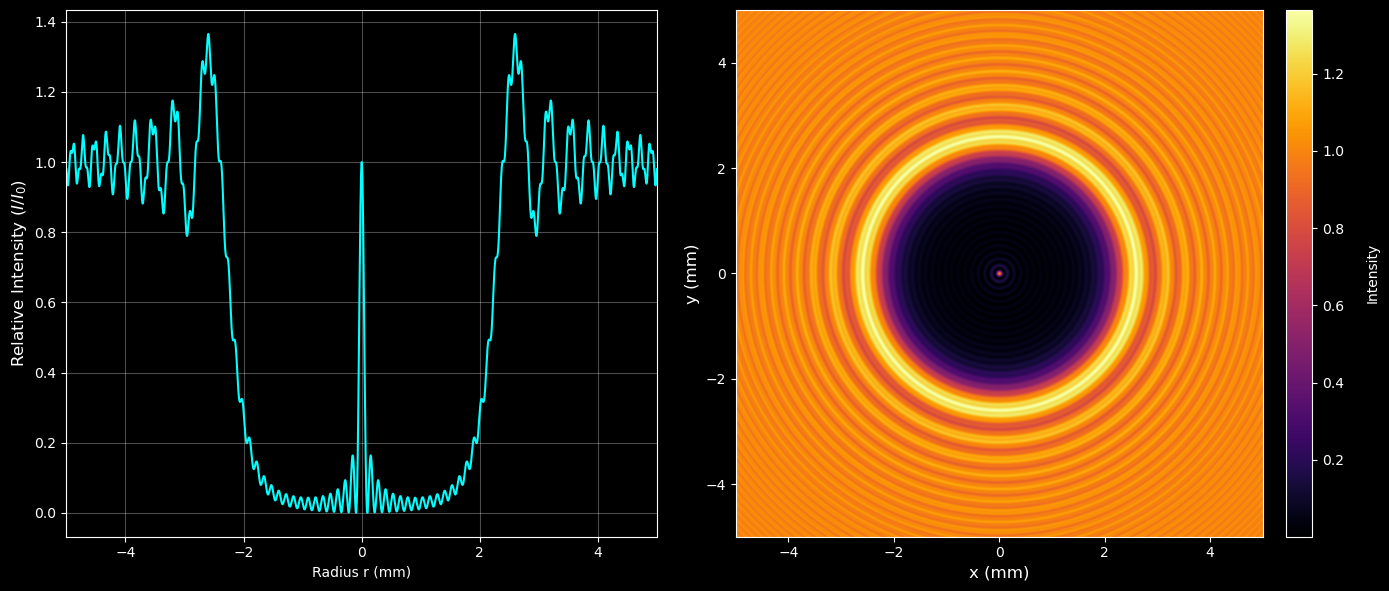

In [13]:
plot_arago(r=5e-3, n_r=10000, z=1.0, wavelength=500e-9, disk_radius=2e-3, I0=1.0, n_xy=2000, n_rp=10000)

generalized incident plane wave (small angles)

In [14]:
z_dist = 1.0 
theta_deg = -0.1
phi_deg = 90.1
wavelength = 500e-9

r_screen = 5e-3
n_xy = 500

I_2D = intensity_arago_2D(r_screen, n_xy,
                          z=z_dist, wavelength=wavelength, disk_radius=2e-3, I0=1.0, theta=theta_deg, phi=phi_deg,
                          n_rp=3000, n_batch=50, process_time=True)

Time taken: 0 mins 36.30 seconds



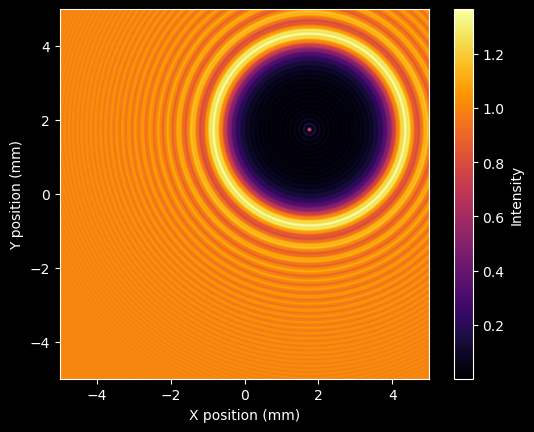

In [15]:
plt.imshow(I_2D, extent=(-r_screen*1000, r_screen*1000, -r_screen*1000, r_screen*1000), cmap='inferno', origin='lower')
plt.xlabel("X position (mm)")
plt.ylabel("Y position (mm)")
plt.colorbar(label="Intensity")
plt.show()

# General Diffraction

Time taken: 0 mins 1.12 seconds



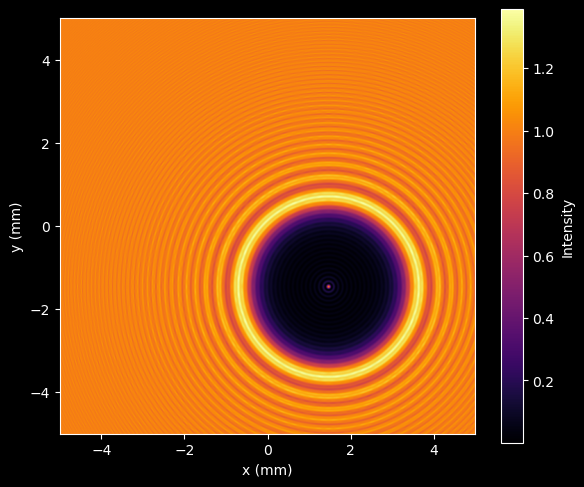

In [17]:
disk_radius = 2e-3

def arago_disk(X, Y, xp):
    R = xp.sqrt(X**2 + Y**2)
    return (R > disk_radius).astype(float)

z_dist = 1
theta_deg = 0.1
phi_deg = 90.1
wavelength = 500e-9

screen_length = 40e-3
n_xy = int(screen_length/2e-5)
I0 = 1.0

I_fft, x, y = intensity_diffraction(
    I0=I0,
    phi=phi_deg,
    theta=theta_deg,
    wavelength=wavelength,
    z=z_dist,
    aperture_func=arago_disk,
    screen_length=screen_length,
    n_grid=n_xy,
    process_time=True
)

plt.figure(figsize=(6,5))

half_display = 6e-3  # 5 mm
mask_x = np.abs(x) <= half_display
mask_y = np.abs(y) <= half_display
I_cropped = I_fft[np.ix_(mask_y, mask_x)]

plt.imshow(I_cropped,
           extent=(-5,5,-5,5),
           cmap='inferno', origin='lower')

plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label="Intensity")
plt.tight_layout()
plt.show()

Time taken: 0 mins 0.23 seconds



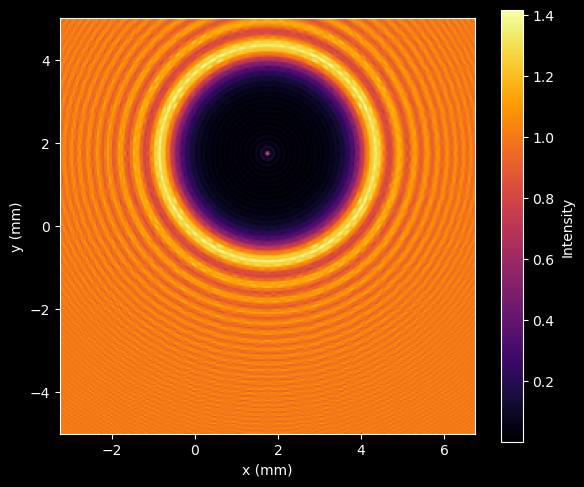

In [18]:
disk_radius = 2e-3

def circular_obstacle(X, Y, xp):
    R = xp.sqrt(X**2 + Y**2)
    return (R > disk_radius).astype(float)

z_dist = 1
theta_deg = -0.1
phi_deg = 90.1
wavelength = 500e-9

screen_length = 40e-3
n_xy = 2**10
I0 = 1.0

I_fft_obs, x, y = intensity_diffraction(
    I0=I0, phi=phi_deg, theta=theta_deg, wavelength=wavelength,
    z=z_dist, aperture_func=circular_obstacle,
    screen_length=screen_length, n_grid=n_xy, process_time=True
)

plt.figure(figsize=(6,5))


shift_x = z_dist * np.tan(np.radians(phi_deg - 90))
shift_y = 0.0

window_radius = 5e-3  # 5 mm view window
mask_x = (x >= shift_x - window_radius) & (x <= shift_x + window_radius)
mask_y = (y >= shift_y - window_radius) & (y <= shift_y + window_radius)

I_cropped_obs = I_fft_obs[np.ix_(mask_y, mask_x)]

plt.imshow(I_cropped_obs,
           extent=((shift_x - window_radius)*1000, (shift_x + window_radius)*1000, 
                   (shift_y - window_radius)*1000, (shift_y + window_radius)*1000),
           cmap='inferno', origin='lower')


plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label="Intensity")
plt.tight_layout()
plt.show()